In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
products = pd.read_csv(
    "../data/raw/digikala-products.csv",
    low_memory=False
)

products.head()

,id,title_fa,Rate,Rate_cnt,Category1,Category2,Brand,Price,Seller,Is_Fake,min_price_last_month,sub_category
0,7096438,آبسلانگ مدل s5 بسته 250 عددی,90,4,آبسلانگ,NaN,متفرقه,634800,سلامت ساز راد,False,0,beauty
1,2845119,آبسلانگ مدل M-1 بسته 400 عددی,84,217,آبسلانگ,NaN,متفرقه,818800,مهر افزون,False,0,beauty
2,6117745,آبسلانگ مدل m50 مجموعه 500 عددی,88,14,آبسلانگ,NaN,متفرقه,920000,یانگوم,False,0,beauty
3,1912926,استند ابسلانگ مدل S01,78,25,آبسلانگ,NaN,متفرقه,1100000,بهراد طب بیدار,False,0,beauty
4,6335462,آبسلانگ نوری تسلامد مدل All-in-One,84,25,آبسلانگ,NaN,تسلا مد,1530000,دیجی‌کالا,False,0,beauty


In [4]:
comments = pd.read_csv(
    "../data/raw/digikala-comments.csv",
    low_memory=False
)

comments.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,NaN,NaN,0,0,دیجی‌کالا,5A52N,NaN
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,NaN
2,38074516,برس ریمل,بسته بندیش خوب بود\r\n کاربرد و کیفیتشم خیلی خ...,26 مرداد 1401,0.0,recommended,True,3331597,NaN,NaN,0,0,آرالیا بیوتی,ADM47,NaN
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,NaN,NaN,0,0,اینجاست آ,9ZMCZ,NaN
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,NaN,NaN,0,0,گالری آرایشی به سیما,CDWHA,NaN


In [5]:
print(products.shape)
print(comments.shape)

(1283496, 12)
(6156289, 15)


In [6]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 1283496 entries, 0 to 1283495
Data columns (total 12 columns):
 #   Column                Non-Null Count    Dtype
---  ------                --------------    -----
 0   id                    1283496 non-null  int64
 1   title_fa              1283496 non-null  str  
 2   Rate                  1283496 non-null  int64
 3   Rate_cnt              1283496 non-null  int64
 4   Category1             1283496 non-null  str  
 5   Category2             1073388 non-null  str  
 6   Brand                 1283496 non-null  str  
 7   Price                 1283496 non-null  int64
 8   Seller                1283273 non-null  str  
 9   Is_Fake               1283496 non-null  bool 
 10  min_price_last_month  1283496 non-null  int64
 11  sub_category          1283496 non-null  str  
dtypes: bool(1), int64(5), str(6)
memory usage: 108.9 MB


In [7]:
comments.info()

<class 'pandas.DataFrame'>
RangeIndex: 6156289 entries, 0 to 6156288
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   title                  str    
 2   body                   str    
 3   created_at             str    
 4   rate                   float64
 5   recommendation_status  str    
 6   is_buyer               bool   
 7   product_id             int64  
 8   advantages             str    
 9   disadvantages          str    
 10  likes                  int64  
 11  dislikes               int64  
 12  seller_title           str    
 13  seller_code            str    
 14  true_to_size_rate      str    
dtypes: bool(1), float64(1), int64(4), str(9)
memory usage: 663.4 MB


In [8]:
products.isnull().sum().sort_values(
    ascending=False
)

Category2               210108
Seller                     223
id                           0
title_fa                     0
Rate_cnt                     0
Rate                         0
Brand                        0
Category1                    0
Price                        0
Is_Fake                      0
min_price_last_month         0
sub_category                 0
dtype: int64

In [9]:
comments.isnull().sum().sort_values(
    ascending=False
)

true_to_size_rate        6065516
disadvantages            5744017
advantages               5448084
title                    2865062
recommendation_status     894426
seller_title              302181
seller_code               302181
body                         637
rate                           0
created_at                     0
id                             0
is_buyer                       0
product_id                     0
likes                          0
dislikes                       0
dtype: int64

In [10]:
products["id"].duplicated().sum()

np.int64(335144)

In [11]:
comments["id"].duplicated().sum()

np.int64(3229)

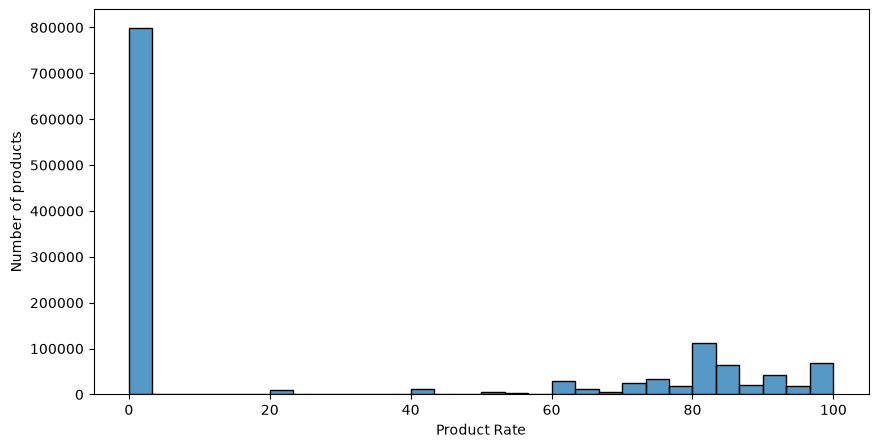

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    products["Rate"].dropna(),
    bins=30
)

plt.xlabel("Product Rate")
plt.ylabel("Number of products")

plt.show()

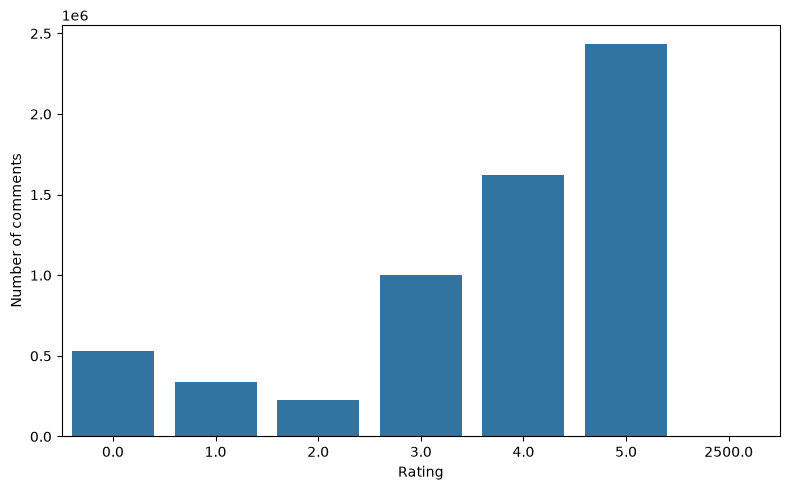

In [23]:
rate_round = comments["rate"].round().value_counts().sort_index()

plt.figure(figsize=(8,5))

sns.barplot(
    x=rate_round.index,
    y=rate_round.values
)

plt.xlabel("Rating")
plt.ylabel("Number of comments")
plt.tight_layout()

plt.show()

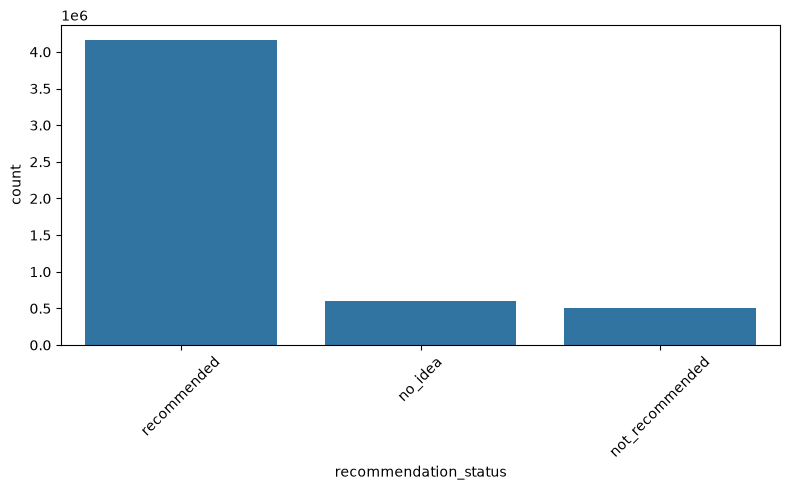

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=comments,
    x="recommendation_status",
    order=comments["recommendation_status"].value_counts().index
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [34]:
pd.crosstab(
    comments["rate"],
    comments["recommendation_status"],
    normalize="index"
)

recommendation_status,no_idea,not_recommended,recommended
rate,,,
0.00,0.040835,0.113996,0.845170
0.05,0.106383,0.861702,0.031915
0.10,0.274194,0.645161,0.080645
0.15,0.439306,0.161850,0.398844
0.20,0.057895,0.429825,0.512281
...,...,...,...
4.85,0.013910,0.003864,0.982226
4.88,0.000000,0.000000,1.000000
4.90,0.013405,0.002681,0.983914


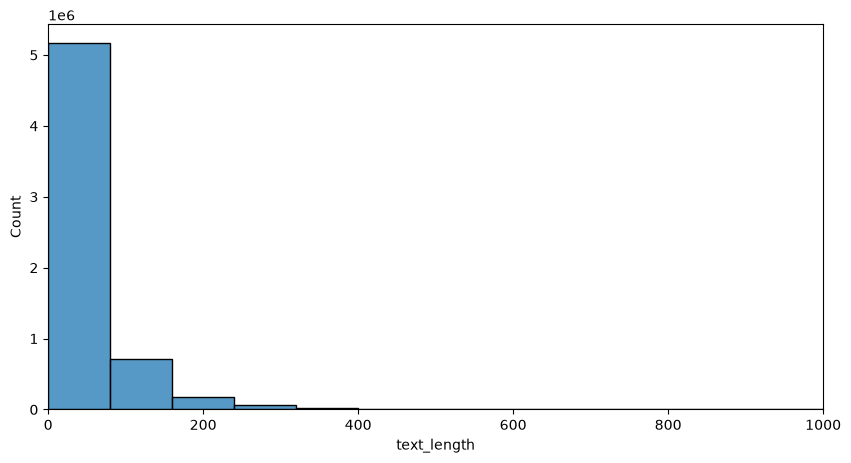

In [29]:
comments["text_length"] = (
    comments["body"]
    .fillna("")
    .str.len()
)

plt.figure(figsize=(10,5))

sns.histplot(
    comments["text_length"],
    bins=50
)

plt.xlim(0,1000)

plt.show()